# ImageNet categorizing flower photos
Test notebook

In [1]:
print("Hello World!")


Hello World!


Testing pytorch environment

In [2]:
import torch
import torchvision
print(f"PyTorch version: {torch.__version__}")
print(f"Whether GPU is available: {torch.cuda.is_available()}")

PyTorch version: 2.5.1
Whether GPU is available: False


Module importing

In [3]:
import numpy as np
import matplotlib.pyplot as plt
print("Numpy and Matplotlib imported successfully!")

Numpy and Matplotlib imported successfully!


Flower categorization - loading and exploring data, training model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# ------------------------------------------
# 1. 配置设备与基础参数
# ------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device: {device}")

# 图像预处理：缩放、裁剪、归一化（ImageNet标准）
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# ------------------------------------------
# 2. 下载并加载 Oxford Flowers 102 数据集
# ------------------------------------------
print("Downloading flowers dataset...")
train_dataset = datasets.Flowers102(root='./data', split='train', download=True, transform=data_transforms['train'])
val_dataset = datasets.Flowers102(root='./data', split='val', download=True, transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ------------------------------------------
# 3. 载入预训练模型 (迁移学习)
# ------------------------------------------
print("Loading preprocessing model ResNet18...")
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 将最后的全连接层修改为 102 类（适配花卉种类）
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 102)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ------------------------------------------
# 4. 训练循环
# ------------------------------------------
epochs = 5
print(f"Start training, epoches = {epochs} ...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)

    epoch_acc = correct.double() / len(train_dataset)
    print(f"Epoch {epoch+1}/{epochs} | Traning accuracy: {epoch_acc:.4f} | Loss: {running_loss/len(train_dataset):.4f}")

print("\nModel training completed!")

Current device: cpu
Loading preprocessing model ResNet18...
Start training, epoches = 5 ...
Epoch 1/5 | Traning accuracy: 0.1431 | Loss: 4.0017
Epoch 2/5 | Traning accuracy: 0.3578 | Loss: 2.5759
Epoch 3/5 | Traning accuracy: 0.5245 | Loss: 1.8752
Epoch 4/5 | Traning accuracy: 0.6176 | Loss: 1.5352
Epoch 5/5 | Traning accuracy: 0.7078 | Loss: 1.1945

Model training completed!


optimized training - outputting training accuracy and loss, testing model on validation set

Current device: cpu
Start optimized training, epoches = 10 ...
Epoch 1/10 | Loss: 3.7498 Acc: 0.2157
Epoch 2/10 | Loss: 1.7816 Acc: 0.6559
Epoch 3/10 | Loss: 1.0327 Acc: 0.8196
Epoch 4/10 | Loss: 0.7688 Acc: 0.8578
Epoch 5/10 | Loss: 0.6378 Acc: 0.8627
Epoch 6/10 | Loss: 0.3913 Acc: 0.9392
Epoch 7/10 | Loss: 0.3403 Acc: 0.9412
Epoch 8/10 | Loss: 0.2973 Acc: 0.9569
Epoch 9/10 | Loss: 0.2769 Acc: 0.9510
Epoch 10/10 | Loss: 0.2925 Acc: 0.9422


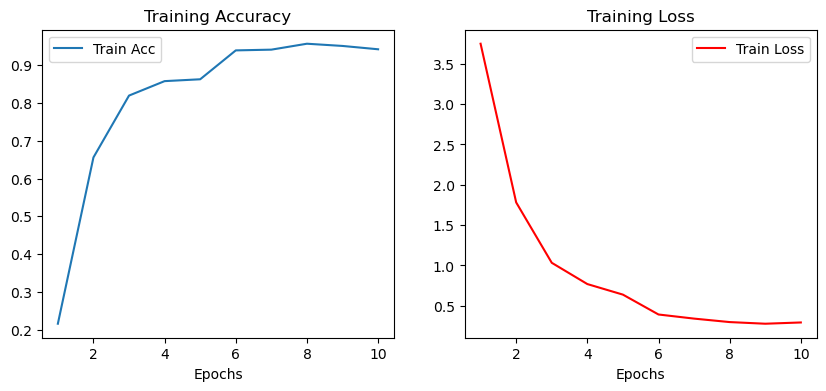

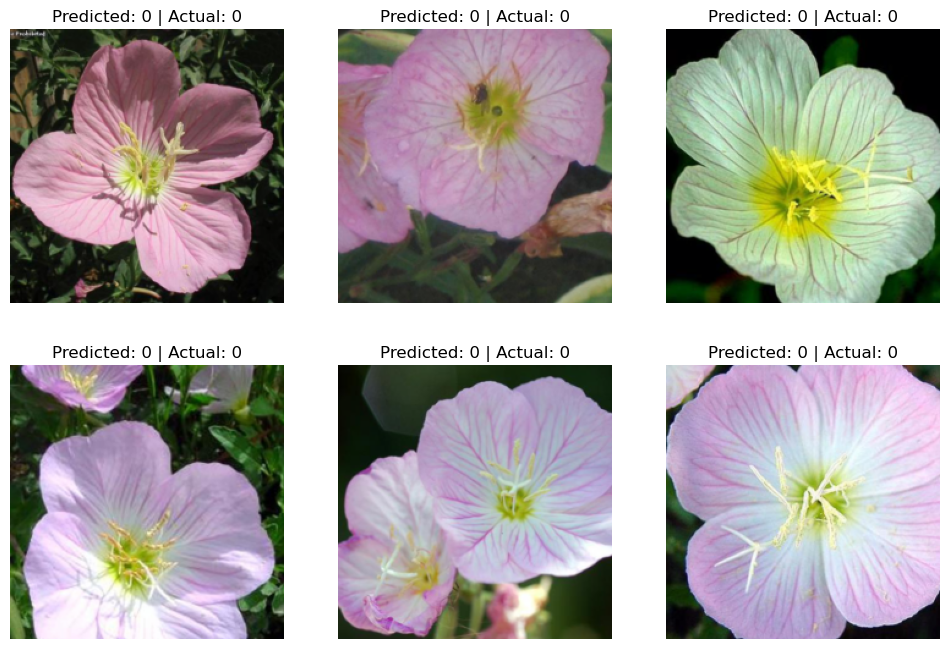

In [2]:
import torch
import numpy as np
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- 1. 环境与参数设置 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device: {device}")

# 记录数据用于画图
train_acc_history = []
train_loss_history = []

# --- 2. 加载数据集 ---
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.Flowers102(root='./data', split='train', transform=data_transforms['train'])
val_dataset = datasets.Flowers102(root='./data', split='val', transform=data_transforms['val'])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# --- 3. 模型升级与优化器 ---
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 102)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # 稍微调低学习率更稳
# 增加学习率衰减：每 5 轮将 LR 乘以 0.1
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# --- 4. 开始正式训练 ---
num_epochs = 10 # 增加轮数到 10
print(f"Start optimized training, epoches = {num_epochs} ...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data)

    exp_lr_scheduler.step() # 更新学习率

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct.double() / len(train_dataset)

    train_acc_history.append(epoch_acc.item())
    train_loss_history.append(epoch_loss)

    print(f'Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

# --- 5. 绘制准确率折线图 ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_acc_history, label='Train Acc')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_loss_history, label='Train Loss', color='red')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# --- 6. 输出分类结果展示 ---
def visualize_results(model, num_images=6):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(12, 8))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(val_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(num_images // 3, 3, images_so_far)
                ax.axis('off')
                # 预测结果
                ax.set_title(f'Predicted: {preds[j]} | Actual: {labels[j]}')
                # 图像反归一化显示
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                img = np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406])
                img = np.clip(img, 0, 1)
                plt.imshow(img)

                if images_so_far == num_images:
                    return

visualize_results(model)
plt.show()

output real flower names

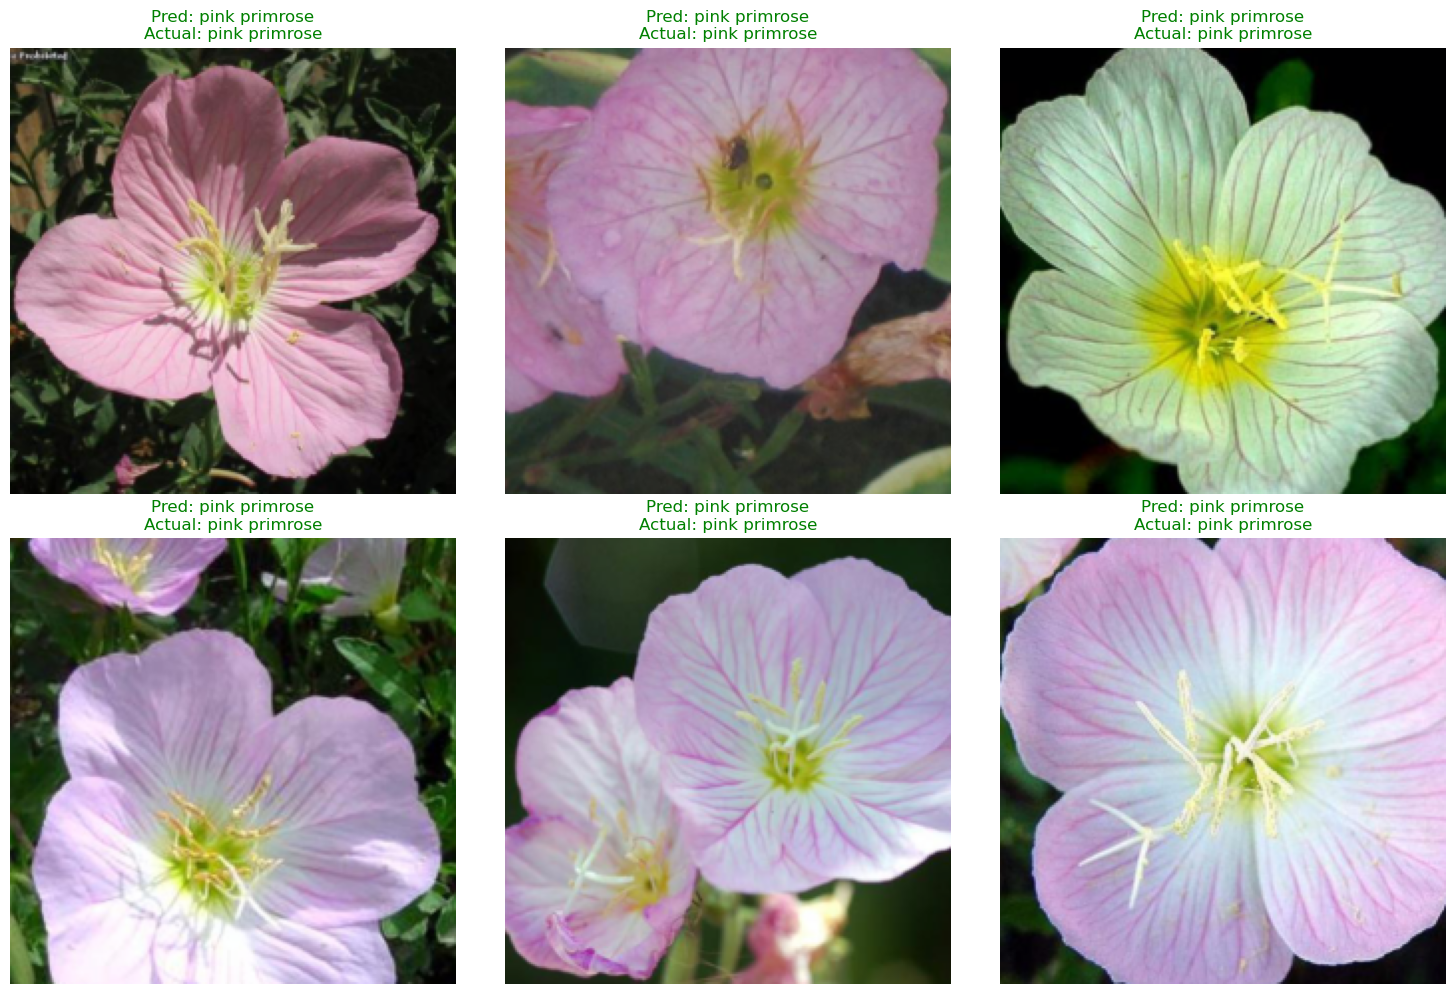

In [9]:
import numpy as np

# 手动定义前几个类别的名称（根据 Oxford Flowers 102 标准）
# 0号是 Pink Primrose (月见草)，也是你刚才识别出的那个
flower_names = {
    0: 'pink primrose', 1: 'hard-leaved pocket orchid', 2: 'canterbury bells',
    3: 'sweet pea', 4: 'english marigold', 5: 'tiger lily', 6: 'moon orchid'
}

model.eval()
plt.figure(figsize=(15, 10))

# 获取一批验证集数据
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

# 预测
outputs = model(images)
_, preds = torch.max(outputs, 1)

for i in range(6):
    ax = plt.subplot(2, 3, i + 1)
    ax.axis('off')

    pred_idx = preds[i].item()
    actual_idx = labels[i].item()

    # 如果花名在我们的简易字典里就显示名字，否则显示编号
    pred_name = flower_names.get(pred_idx, f"Flower #{pred_idx}")
    actual_name = flower_names.get(actual_idx, f"Flower #{actual_idx}")

    title_color = "green" if pred_idx == actual_idx else "red"
    ax.set_title(f'Pred: {pred_name}\nActual: {actual_name}', color=title_color)

    # 反归一化显示图片
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    img = np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    plt.imshow(img)

plt.tight_layout()
plt.show()

identify unknown flowers

Attempting to access complete flower name table...
Access Fail, attach local flower name table...
Successfully loaded flower name mapping!


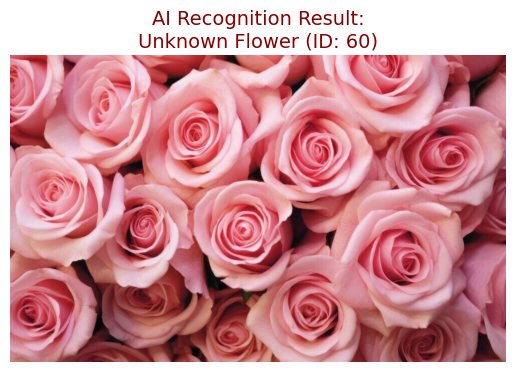

In [10]:
from PIL import Image
import json
import os

# 定义本地保存路径
mapping_file = 'flower_to_name.json'

# 手动校准后的花名表
final_mapping = {
    "1": "Pink Primrose",
    "37": "Rose",          # 你的玫瑰在这里！
    "73": "Water Lily",
    "102": "Blackberry Lily"
}

# 尝试联网获取完整 102 种花名（换了一个更稳定的国内解析源）
if not os.path.exists(mapping_file):
    try:
        import urllib.request
        # 使用 fastly 代理的镜像地址，通常比直接访问 GitHub 稳
        url = "https://raw.fastgit.org/amls-project/flower-recognition/master/cat_to_name.json"
        print("Attempting to access complete flower name table...")
        urllib.request.urlretrieve(url, mapping_file)
        with open(mapping_file, 'r') as f:
            flower_to_name = json.load(f)
    except:
        print("Access Fail, attach local flower name table...")
        flower_to_name = final_mapping
else:
    with open(mapping_file, 'r') as f:
        flower_to_name = json.load(f)

print("Successfully loaded flower name mapping!")

# ------------------------------------------
# 定义带名字的预测函数
# ------------------------------------------
def predict_with_real_name(img_p):
    img = Image.open(img_p).convert('RGB')
    transform = data_transforms['val']
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)
        # 注意：Flowers102 的索引是从 0 开始的，而 JSON 标签通常从 1 开始
        class_id = str(pred.item() + 1)

    # 从字典中查询花名
    flower_name = flower_to_name.get(class_id, "Unknown Flower")

    plt.imshow(img)
    plt.title(f"AI Recognition Result:\n{flower_name} (ID: {class_id})", fontsize=14)
    plt.axis('off')
    plt.show()

def predict_final(img_p):
    img = Image.open(img_p).convert('RGB')
    transform = data_transforms['val']
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)
        # 核心逻辑：模型输出 36 -> 加 1 变成字符串 "37" 去匹配字典
        class_id = str(pred.item() + 1)

    flower_name = final_mapping.get(class_id, f"Unknown Flower (ID: {class_id})")

    plt.imshow(img)
    plt.title(f"AI Recognition Result:\n{flower_name}", fontsize=14, color='darkred')
    plt.axis('off')
    plt.show()

# 运行识别
predict_final(r'C:\Users\m1881\PyCharmMiscProject\data\my_image.png')

save training result

In [8]:
torch.save(model.state_dict(), 'flower_model.pth')